In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\subham\Desktop\TekWorks\Decision_Task\dataset_task.csv')
df

,ID,Age,Agency,Agency Type,Commision (in value),Destination,Distribution Channel,Duration,Gender,Net Sales,Product Name,Claim
0,45341,28,C2B,Airlines,28.13,SINGAPORE,Online,34,F,112.5,Silver Plan,1
1,12958,37,JZI,Airlines,12.95,PHILIPPINES,Online,53,F,37.0,Basic Plan,0
2,18233,27,EPX,Travel Agency,0.00,UNITED STATES,Online,28,NaN,13.0,Cancellation Plan,0
3,31742,36,EPX,Travel Agency,0.00,SAUDI ARABIA,Online,1,NaN,34.0,Cancellation Plan,0
4,14381,26,CWT,Travel Agency,23.76,THAILAND,Online,33,NaN,39.6,Rental Vehicle Excess Insurance,0
...,...,...,...,...,...,...,...,...,...,...,...,...
62283,36315,36,EPX,Travel Agency,0.00,HONG KONG,Online,17,NaN,28.0,2 way Comprehensive Plan,0
62284,2511,56,JZI,Airlines,9.10,AUSTRALIA,Online,9,F,26.0,Basic Plan,0
62285,16874,36,EPX,Travel Agency,0.00,ITALY,Online,216,NaN,20.0,2 way Comprehensive Plan,1
62286,14801,29,CWT,Travel Agency,11.88,AUSTRALIA,Online,37,NaN,19.8,Rental Vehicle Excess Insurance,1


In [3]:
df.isnull().sum()

ID                          0
Age                         0
Agency                      0
Agency Type                 0
Commision (in value)        0
Destination                 0
Distribution Channel        0
Duration                    0
Gender                  39575
Net Sales                   0
Product Name                0
Claim                       0
dtype: int64

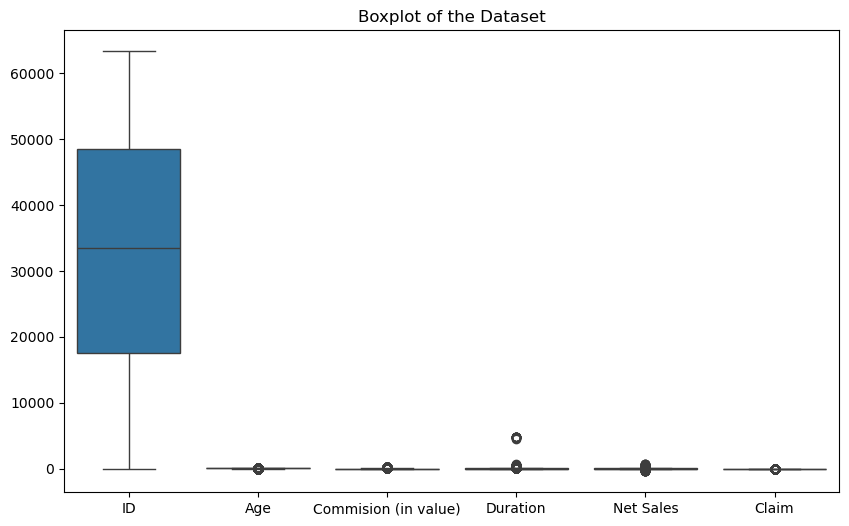

In [4]:
# Show the outliers using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of the Dataset')
plt.show()

In [5]:
# Remove the Outlier from the duration column
Q1 = df['Duration'].quantile(0.25)
Q3 = df['Duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Duration'] >= lower_bound) & (df['Duration'] <= upper_bound)]

In [6]:
df

,ID,Age,Agency,Agency Type,Commision (in value),Destination,Distribution Channel,Duration,Gender,Net Sales,Product Name,Claim
0,45341,28,C2B,Airlines,28.13,SINGAPORE,Online,34,F,112.5,Silver Plan,1
1,12958,37,JZI,Airlines,12.95,PHILIPPINES,Online,53,F,37.0,Basic Plan,0
2,18233,27,EPX,Travel Agency,0.00,UNITED STATES,Online,28,NaN,13.0,Cancellation Plan,0
3,31742,36,EPX,Travel Agency,0.00,SAUDI ARABIA,Online,1,NaN,34.0,Cancellation Plan,0
4,14381,26,CWT,Travel Agency,23.76,THAILAND,Online,33,NaN,39.6,Rental Vehicle Excess Insurance,0
...,...,...,...,...,...,...,...,...,...,...,...,...
62282,58235,31,CWT,Travel Agency,29.70,AUSTRALIA,Online,15,NaN,49.5,Rental Vehicle Excess Insurance,0
62283,36315,36,EPX,Travel Agency,0.00,HONG KONG,Online,17,NaN,28.0,2 way Comprehensive Plan,0
62284,2511,56,JZI,Airlines,9.10,AUSTRALIA,Online,9,F,26.0,Basic Plan,0
62286,14801,29,CWT,Travel Agency,11.88,AUSTRALIA,Online,37,NaN,19.8,Rental Vehicle Excess Insurance,1


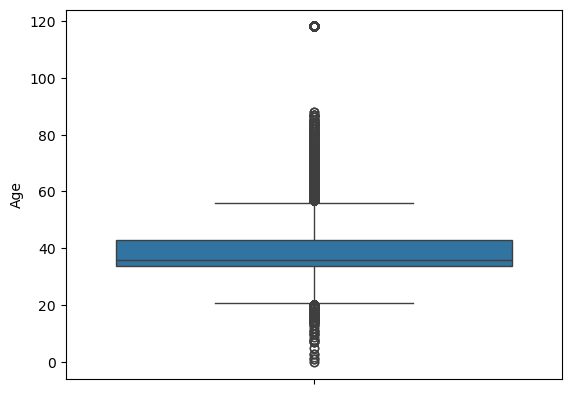

In [7]:
Age_boxplot = sns.boxplot(y=df['Age'])

In [8]:
## remove outliers from age
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

In [9]:
## removing null values from gender
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Windows\Temp\ipykernel_16656\845980524.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Windows\Temp\ipykernel_16656\845980524.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [10]:
#keep only top 5 agencies and replace the rest with other
top_agencies = df['Agency'].value_counts().nlargest(5).index
df['Agency'] = df['Agency'].apply(lambda x: x if x in top_agencies else 'other')

C:\Windows\Temp\ipykernel_16656\2844977106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Agency'] = df['Agency'].apply(lambda x: x if x in top_agencies else 'other')
